In [199]:
import pandas as pd
import numpy as np

data = pd.read_csv('data.csv')
print(data.info())
print(data.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   post_datetime            2000 non-null   float64
 1   views                    2000 non-null   float64
 2   likes                    2000 non-null   float64
 3   comments                 2000 non-null   float64
 4   shares                   2000 non-null   float64
 5   engagement_rate          2000 non-null   float64
 6   sentiment_score          2000 non-null   float64
 7   platform_Instagram       2000 non-null   int64  
 8   platform_TikTok          2000 non-null   int64  
 9   platform_X               2000 non-null   int64  
 10  platform_YouTube Shorts  2000 non-null   int64  
 11  content_type_carousel    2000 non-null   int64  
 12  content_type_image       2000 non-null   int64  
 13  content_type_text        2000 non-null   int64  
 14  content_type_video      

In [215]:
import numpy as np

class MyLinearRegressor:
    def __init__(self, l2=0.1):
        if l2 < 0:
            raise ValueError("l2 must be positive")
        self.l2 = l2
        self.W = None
        self.b = None
        self.weights = None

    def fit(self, X, Y):
        ones = np.ones((X.shape[0], 1))
        X_with_bias = np.hstack([ones, X])

        n_features_with_bias = X_with_bias.shape[1]

        reg_matrix = self.l2 * np.eye(n_features_with_bias)
        reg_matrix[0, 0] = 0

        cov = X_with_bias.T.dot(X_with_bias) + reg_matrix
        self.W = np.linalg.solve(cov, X_with_bias.T.dot(Y))

        self.b = self.W[0]
        self.weights = self.W[1:]

        return self

    def predict(self, X):
        return X.dot(self.weights) + self.b

In [253]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


target = 'views'

X = data.drop(columns=[target])
y = data[target]

print(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

0      -0.605709
1      -0.538117
2      -0.996395
3       0.303995
4      -0.338513
          ...   
1995    3.028095
1996    0.406696
1997   -0.694199
1998    0.293491
1999   -0.282072
Name: views, Length: 2000, dtype: float64


In [254]:


best = [float('inf'), -1]
for l2 in [0, 0.1, 0.01, 1, 10, 12, 15, 20, 25, 70, 100]:
  model = MyLinearRegressor(l2)
  model.fit(np.array(X_train), np.array(y_train))
  y_pred = model.predict(X_test)
  mse_error = mean_squared_error(y_pred, y_test)

  print(l2, mse_error)

  if mse_error < best[0]:
    best[0] = mse_error
    best[1] = l2

print(*best)
# print(y_pred)

0 0.3292524078563194
0.1 0.32924955976889037
0.01 0.32925212232600193
1 0.32922464315124683
10 0.32904138038256364
12 0.32901559084973236
15 0.3289861343721324
20 0.32896007263088367
25 0.32896050519080705
70 0.3298527215815837
100 0.33106397477380034
0.32896007263088367 20


In [256]:
class MyLinearClassificator(MyLinearRegressor):
  def __init__(self, l2=0):
    super().__init__(l2)
    self.classes_ = None

  def fit(self, X, y):
    neg_class, pos_class = np.unique(y)[0], np.unique(y)[1]
    y_binary = np.where(y == neg_class, -1, 1)
    self.classes_ = np.unique(y)

    super().fit(X, y_binary)
    return self

  def predict(self, X):
    y_pred_binary = np.sign(super().predict(X))
    y_pred_binary[y_pred_binary == 0] = 1

    neg_class, pos_class = self.classes_[0], self.classes_[1]
    return np.where(y_pred_binary == 1, pos_class, neg_class)

In [257]:
target = 'is_viral'

X = data.drop(columns=[target])
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [222]:
from sklearn.metrics import precision_score

best = [float('inf'), -1]
for l2 in [0, 0.1, 0.01, 1, 10, 12, 15, 20, 24]:
  model = MyLinearClassificator(l2)
  model.fit(np.array(X_train), np.array(y_train))
  y_pred = model.predict(X_test)
  pr_error = precision_score(y_pred, y_test)

  if pr_error < best[0]:
    best[0] = pr_error
    best[1] = l2

print(*best)
print(y_pred)

0.927797833935018 0
[1 0 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 0 0 1 1 1 0 1 1 1 1 1 0 0 0 0 1 1 1 0
 0 1 0 1 1 0 1 0 1 1 1 1 0 0 1 0 0 1 1 1 1 0 1 0 1 1 1 0 1 1 1 1 1 1 1 1 1
 1 1 0 0 0 1 1 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 1 0 0 1 1 0 1 1 0 1 1 1 1 0 1
 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0 0 1 0 1 1 0 1 0 1 0 1 1 1 1 0 0
 1 1 1 0 1 0 1 1 0 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 0 0 0
 1 1 1 0 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 0 0 1 1 0 1 1 1 1 1 1
 1 0 1 0 1 1 0 1 1 1 0 1 0 1 1 0 1 1 1 1 0 1 1 1 0 1 0 0 1 0 1 1 1 1 1 1 1
 0 1 1 1 0 0 1 1 0 1 1 1 1 0 1 0 1 1 1 1 0 0 1 1 1 1 1 0 1 0 1 1 0 1 0 0 0
 1 0 0 1 1 1 1 1 1 1 1 0 1 1 1 0 1 1 1 0 1 1 0 0 1 1 1 1 0 0 1 1 1 1 1 1 1
 1 1 0 1 0 1 1 0 1 0 0 1 1 1 0 0 1 0 0 0 1 0 0 1 1 1 1 1 0 1 0 1 1 0 1 1 0
 1 1 0 1 1 0 0 0 1 1 1 1 0 0 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 0]


In [206]:
class FdF:
  def __init__(self, f, df):
    self.f = f
    self.df = df

  def forward(self, m):
    return self.f(m)

  def backward(self, m):
    return self.df(m)

class RidgeLoss(FdF):
  def __init__(self):
    super().__init__(lambda m: (1 - m) ** 2, lambda m: -2 * (1 - m))

class LogLoss(FdF):
  def __init__(self):
    super().__init__(lambda m: np.log(1 + np.e ** (-m)), lambda m: -1 / (1 + np.e ** m))

class HingeLoss(FdF):
  def __init__(self):
    super().__init__(lambda m: np.maximum(0, 1 - m), lambda m: -1.0 * (m < 1).astype(float))


In [249]:
class L2Reg(FdF):
  def __init__(self, l2=0.01):
    assert l2 >= 0, "l2 must be positive"
    super().__init__(
        lambda x: l2 * np.linalg.norm(x, ord=2)**2,
        lambda x: l2 * 2 * x,
      )

class L1Reg(FdF):
  def __init__(self, l1=0.01):
    assert l1 >= 0, "l1 must be positive"
    super().__init__(
        lambda x: l1 * np.linalg.norm(x, ord=1),
        lambda x: l1 * np.sign(x),
      )

class ElasticNetReg(FdF):
  def __init__(self, a=1, l1=0.01):
    assert l1 >= 0 and a >= 0, "l1 and a must be positive"
    super().__init__(
        lambda x: a * (l1 * np.linalg.norm(x, ord=1) + (1 - l1) * np.linalg.norm(x, ord=2)**2),
        # λ(ρ⋅sign(w)+(1−ρ)⋅w)
        lambda x: a * (l1 * np.sign(x) + (1 - l1) * x),
      )

In [250]:
class MyGDClassificator:
  def __init__(self, loss=None, lr=0.01, reg=None, steps=1000, max_steps=10**4):
    self.loss = loss if loss is not None else RidgeLoss()
    self.lr = lr
    self.steps = steps
    self.max_steps = max_steps
    self.reg = reg if reg is not None else L2Reg(0.01)
    self.W = None
    self.bias = None

    self.loss_history = []

  def fit(self, X, y):
    unique_classes = np.unique(y)
    self.class_mapping_ = {unique_classes[0]: -1, unique_classes[1]: 1}
    self.inverse_class_mapping_ = {-1: unique_classes[0], 1: unique_classes[1]}

    y_binary = np.array([self.class_mapping_[val] for val in y])

    n_samples, n_features = X.shape

    self.W = np.zeros(n_features)
    self.bias = 0

    for si in range(min(self.steps, self.max_steps)):
      margins = y_binary * (np.dot(X, self.W) + self.bias)

      current_loss = np.mean(self.loss.forward(margins))
      if self.reg:
          current_loss += self.reg.forward(self.W)
      self.loss_history.append(current_loss)

      grad_loss_per_sample = self.loss.backward(margins) * y_binary
      
      grad_W = np.dot(grad_loss_per_sample, X) / n_samples
      grad_bias = np.sum(grad_loss_per_sample) / n_samples

      if self.reg:
        grad_W += self.reg.backward(self.W)
      
      self.W -= self.lr * grad_W
      self.bias -= self.lr * grad_bias

  def predict(self, X):
    predictions_binary = np.sign(np.dot(X, self.W) + self.bias)
    predictions_binary[predictions_binary == 0] = 1 
    predictions = np.array([self.inverse_class_mapping_[pred] for pred in predictions_binary])

    return predictions

In [251]:
model = MyGDClassificator(steps=1000, reg=L2Reg(0.0001))
model.fit(np.array(X_train), np.array(y_train))
y_pred = model.predict(X_test)
pr_error = precision_score(y_pred, y_test)
print(pr_error)


0.927797833935018


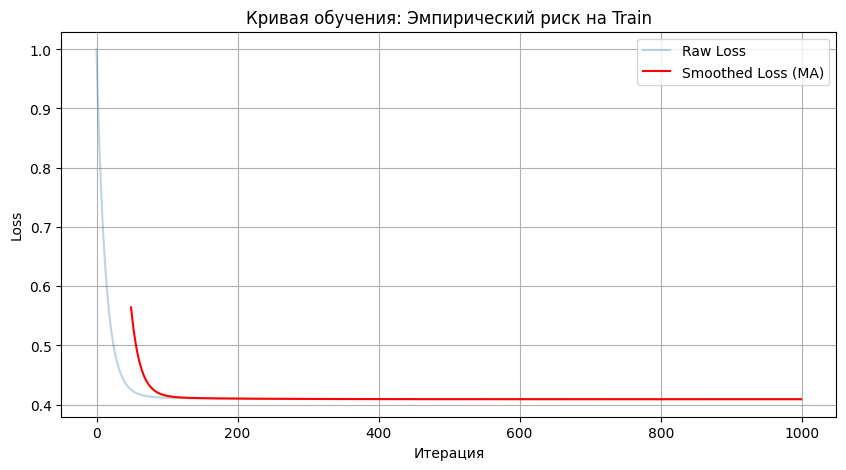

In [230]:
import matplotlib.pyplot as plt

def plot_smoothed_loss(loss_history, window=50):
    smoothed_loss = pd.Series(loss_history).rolling(window=window).mean()
    plt.figure(figsize=(10, 5))
    plt.plot(loss_history, alpha=0.3, label='Raw Loss')
    plt.plot(smoothed_loss, color='red', label='Smoothed Loss (MA)')
    plt.title("Кривая обучения: Эмпирический риск на Train")
    plt.xlabel("Итерация")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

# Использование:
# model.fit(X_train, y_train)
plot_smoothed_loss(model.loss_history)

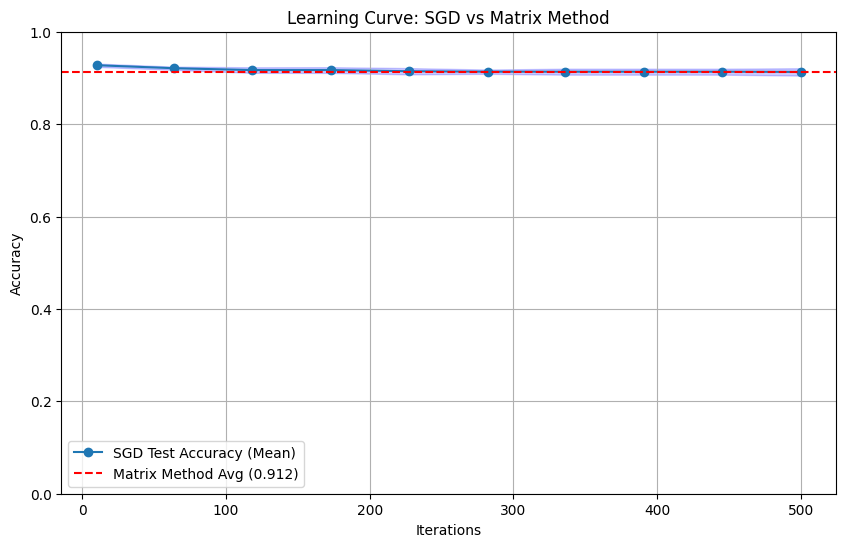

In [258]:
from sklearn.model_selection import ShuffleSplit
from sklearn.metrics import accuracy_score

def plot_learning_curve_with_ci(X, y, n_splits=5, steps=2000):
    X = np.array(X)
    y = np.array(y)
    
    ss = ShuffleSplit(n_splits=n_splits, test_size=0.2, random_state=42)
    
    all_scores = []
    matrix_scores = []
    iterations = np.linspace(10, steps, 10).astype(int) 

    for train_idx, test_idx in ss.split(X):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        
        # Считаем качество матричного метода для этого разбиения
        m_lin = MyLinearClassificator(0.1).fit(X_tr, y_tr)
        matrix_scores.append(accuracy_score(y_te, m_lin.predict(X_te)))
        
        # Считаем GD для разных итераций
        scores_for_split = []
        for s in iterations:
            m_sgd = MyGDClassificator(steps=s, lr=0.01)
            m_sgd.fit(X_tr, y_tr)
            scores_for_split.append(accuracy_score(y_te, m_sgd.predict(X_te)))
        all_scores.append(scores_for_split)

    # Статистика для графика
    all_scores = np.array(all_scores)
    mean_score = np.mean(all_scores, axis=0)
    std_score = np.std(all_scores, axis=0)
    avg_matrix_score = np.mean(matrix_scores)

    plt.figure(figsize=(10, 6))
    
    # GD с тенями
    plt.fill_between(iterations, mean_score - std_score, mean_score + std_score, alpha=0.2, color='blue')
    plt.plot(iterations, mean_score, 'o-', label='SGD Test Accuracy (Mean)')
    
    # Горизонтальная линия (теперь это среднее качество матричного метода)
    plt.axhline(y=avg_matrix_score, color='r', linestyle='--', 
                label=f'Matrix Method Avg ({avg_matrix_score:.3f})')
    
    plt.title("Learning Curve: SGD vs Matrix Method")
    plt.xlabel("Iterations")
    plt.ylabel("Accuracy")
    plt.ylim(0.0, 1.0)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_learning_curve_with_ci(X, y, n_splits=5, steps=500)

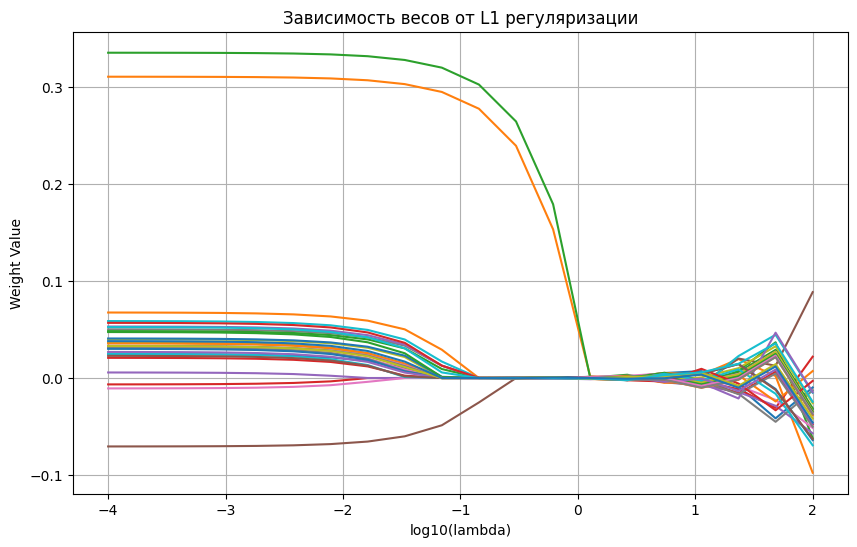

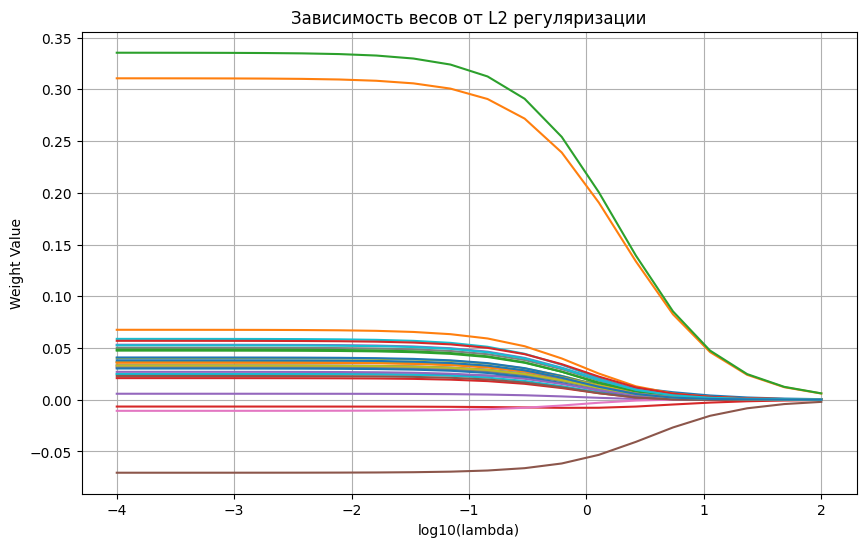

In [259]:
def plot_weights_vs_reg(X, y, reg_type='L1'):
    lambdas = np.logspace(-4, 2, 20)
    weights_history = []

    for l in lambdas:
        reg = L1Reg(l) if reg_type == 'L1' else L2Reg(l)
        m = MyGDClassificator(reg=reg, lr=0.001, steps=1000)
        m.fit(X, y)
        weights_history.append(m.W)

    weights_history = np.array(weights_history)
    
    plt.figure(figsize=(10, 6))
    for i in range(weights_history.shape[1]):
        plt.plot(np.log10(lambdas), weights_history[:, i])
    
    plt.title(f"Зависимость весов от {reg_type} регуляризации")
    plt.xlabel("log10(lambda)")
    plt.ylabel("Weight Value")
    plt.grid(True)
    plt.show()

plot_weights_vs_reg(np.array(X_train), np.array(y_train), 'L1')
plot_weights_vs_reg(np.array(X_train), np.array(y_train), 'L2')